## Retail Sales Performance Analyzer

In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. BASIC PYTHON DATA STRUCTURES: lists & tuples

In [32]:
# A list of store names (lists are ordered and changeable)

store_names = [
    "Cape Town Central Convenience Store", "Sea Point Convenience Store", "Stellenbosch Convenience Store", "Durbanville Convenience Store",
    "Bellville Convenience Store", "Somerset West Convenience Store", "Paarl Convenience Store", "Claremont Convenience Store",
    "Milnerton Convenience Store", "Khayelitsha Convenience Store"]

In [33]:
# A list of product categories

product_categories = ["Beverages", "Snacks", "Household", "Personal Care", "Tobacco Alternatives"]

In [45]:
product_categories = ["Beverages", "Snacks", "Household", "Personal Care", "Tobacco Alternatives"]
regions = ("Western Cape North", "Western Cape South", "Western Cape East")
PERFORMANCE_THRESHOLDS = (130000, 160000)

In [34]:
# A tuple of regions (tuples are ordered but immutable — good for fixed reference data)

regions = ("Western Cape North", "Western Cape South", "Western Cape East")

## 2. NUMPY: generate reproducible random sales data

In [35]:
np.random.seed(42)  

In [36]:
n_records = 200

In [56]:
# n.random.choice picks randomly from our lists/tuples above

sim_stores = np.random.choice(store_names, size=n_records)p
sim_categories = np.random.choice(product_categories, size=n_records)
sim_regions = np.random.choice(regions, size=n_records)

print(sim_stores[:5])
print(sim_categories[:5])
print(sim_regions[:5])

['Stellenbosch Convenience Store' 'Stellenbosch Convenience Store'
 'Durbanville Convenience Store' 'Sea Point Convenience Store'
 'Sea Point Convenience Store']
['Snacks' 'Household' 'Tobacco Alternatives' 'Tobacco Alternatives'
 'Snacks']
['Western Cape East' 'Western Cape North' 'Western Cape East'
 'Western Cape North' 'Western Cape South']


In [58]:
# np.random.normal generates realistic-looking sales figures (mean, std, count)

sim_sales = np.random.normal(loc=7000, scale=2500, size=n_records)
sim_sales = np.round(np.clip(sim_sales, 500, None), 2) 

print(sim_sales[:5])

[5115.09 6298.31 2767.61 6754.15 4528.52]


In [59]:
# np.random.randint for whole-number units sold

sim_units = np.random.randint(5, 300, size=n_records)
print(sim_units[:5])

[ 46  25  46 117 109]


## 3. PANDAS: build the DataFrame

In [40]:
df = pd.DataFrame({
    "store": sim_stores,
    "region": sim_regions,
    "category": sim_categories,
    "units_sold": sim_units,
    "sales_zar": sim_sales,
})

print("=" * 60)
print("RAW DATA SAMPLE (first 5 rows)")
print("=" * 60)
print(df.head())

RAW DATA SAMPLE (first 5 rows)
                           store              region       category  \
0        Paarl Convenience Store  Western Cape North      Household   
1  Durbanville Convenience Store  Western Cape South      Beverages   
2    Claremont Convenience Store  Western Cape North      Beverages   
3    Bellville Convenience Store  Western Cape North  Personal Care   
4        Paarl Convenience Store  Western Cape South      Household   

   units_sold  sales_zar  
0         141    5650.64  
1          80    3450.10  
2          39    4882.67  
3           5    6886.88  
4          64     589.15  


In [60]:
# Add a derived column using NumPy vectorised math

df["avg_price_per_unit"] = np.round(df["sales_zar"] / df["units_sold"], 2)
df.head()

,store,region,category,units_sold,sales_zar,avg_price_per_unit
0,Paarl Convenience Store,Western Cape North,Household,141,5650.64,40.08
1,Durbanville Convenience Store,Western Cape South,Beverages,80,3450.10,43.13
2,Claremont Convenience Store,Western Cape North,Beverages,39,4882.67,125.20
3,Bellville Convenience Store,Western Cape North,Personal Care,5,6886.88,1377.38
4,Paarl Convenience Store,Western Cape South,Household,64,589.15,9.21


## 4. GROUPING & AGGREGATION with Pandas

In [43]:
store_totals = (
    df.groupby("store")["sales_zar"]
    .sum()
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

print("\n" + "=" * 60)
print("TOTAL SALES PER STORE")
print("=" * 60)
print(store_totals)


TOTAL SALES PER STORE
                                 store  sales_zar
0          Claremont Convenience Store  171235.54
1  Cape Town Central Convenience Store  167693.89
2              Paarl Convenience Store  165404.84
3          Milnerton Convenience Store  155360.54
4       Stellenbosch Convenience Store  154387.08
5          Bellville Convenience Store  141315.96
6        Khayelitsha Convenience Store  128158.91
7        Durbanville Convenience Store  124303.17
8          Sea Point Convenience Store  119017.55
9      Somerset West Convenience Store  103772.67


## 5. CONDITIONALS: if / elif / else, inside a for loop

In [46]:
# Classify each store as Underperforming / On Target / Top Performer using the thresholds tuple defined earlier.

performance_labels = [] 

for total_sales in store_totals["sales_zar"]:
    if total_sales < PERFORMANCE_THRESHOLDS[0]:
        performance_labels.append("Underperforming")
    elif total_sales <= PERFORMANCE_THRESHOLDS[1]:
        performance_labels.append("On Target")
    else:
        performance_labels.append("Top Performer")

store_totals["performance"] = performance_labels

print("\n" + "=" * 60)
print("STORE PERFORMANCE CLASSIFICATION")
print("=" * 60)
print(store_totals)


STORE PERFORMANCE CLASSIFICATION
                                 store  sales_zar      performance
0          Claremont Convenience Store  171235.54    Top Performer
1  Cape Town Central Convenience Store  167693.89    Top Performer
2              Paarl Convenience Store  165404.84    Top Performer
3          Milnerton Convenience Store  155360.54        On Target
4       Stellenbosch Convenience Store  154387.08        On Target
5          Bellville Convenience Store  141315.96        On Target
6        Khayelitsha Convenience Store  128158.91  Underperforming
7        Durbanville Convenience Store  124303.17  Underperforming
8          Sea Point Convenience Store  119017.55  Underperforming
9      Somerset West Convenience Store  103772.67  Underperforming


In [61]:
# A simple loop + conditional to print a plain-English summary

print("\n" + "=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)
for _, row in store_totals.iterrows():
    store = row["store"]
    label = row["performance"]
    if label == "Top Performer":
        print(f"⭐ {store} is a TOP PERFORMER — keep doing what works.")
    elif label == "On Target":
        print(f"✅ {store} is ON TARGET.")
    else:
        print(f"❌  {store} is UNDERPERFORMING — needs attention.")


PERFORMANCE SUMMARY
⭐ Claremont Convenience Store is a TOP PERFORMER — keep doing what works.
⭐ Cape Town Central Convenience Store is a TOP PERFORMER — keep doing what works.
⭐ Paarl Convenience Store is a TOP PERFORMER — keep doing what works.
✅ Milnerton Convenience Store is ON TARGET.
✅ Stellenbosch Convenience Store is ON TARGET.
✅ Bellville Convenience Store is ON TARGET.
❌  Khayelitsha Convenience Store is UNDERPERFORMING — needs attention.
❌  Durbanville Convenience Store is UNDERPERFORMING — needs attention.
❌  Sea Point Convenience Store is UNDERPERFORMING — needs attention.
❌  Somerset West Convenience Store is UNDERPERFORMING — needs attention.


## 6. MORE PANDAS: filtering and category breakdown

In [21]:
category_summary = (
    df.groupby("category")
    .agg(total_sales=("sales_zar", "sum"), total_units=("units_sold", "sum"))
    .round(2)
    .sort_values("total_sales", ascending=False)
    .reset_index()
)

print("\n" + "=" * 60)
print("SALES BY PRODUCT CATEGORY")
print("=" * 60)
print(category_summary)


SALES BY PRODUCT CATEGORY
               category  total_sales  total_units
0             Beverages    325057.96         6632
1         Personal Care    303633.46         6050
2             Household    286057.05         6041
3                Snacks    262561.41         6061
4  Tobacco Alternatives    253340.27         5939


In [22]:
# Filtering example: only high-value transactions

high_value_sales = df[df["sales_zar"] > 10000]
print(f"\nNumber of high-value transactions (> R10,000): {len(high_value_sales)}")


Number of high-value transactions (> R10,000): 31


## 7. SEABORN VISUALIZATIONS

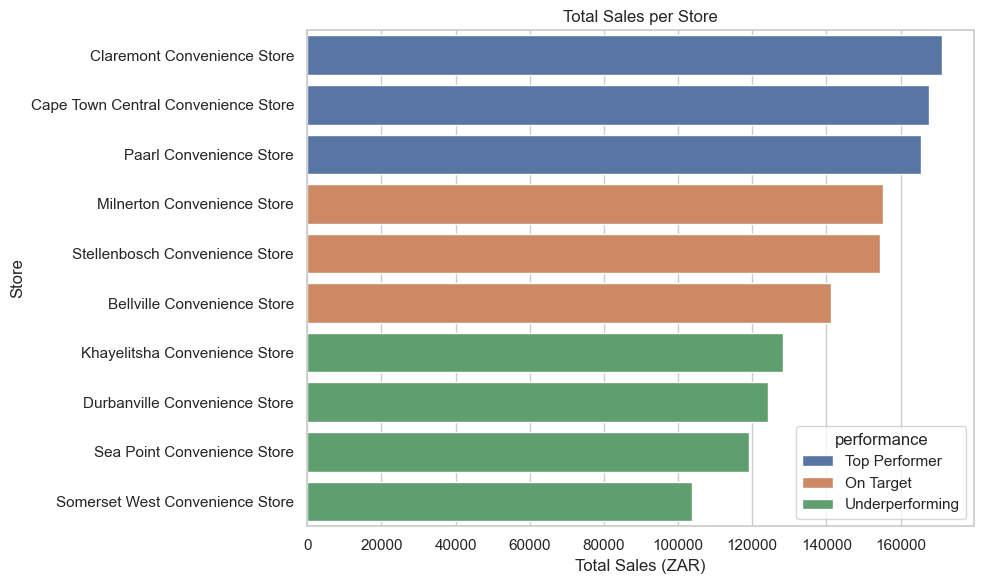

In [52]:
# Chart 1: Bar chart — total sales per store, coloured by performance

plt.figure(figsize=(10, 6))
sns.barplot(
    data=store_totals,
    x="sales_zar",
    y="store",
    hue="performance",
    dodge=False,
)
plt.title("Total Sales per Store")
plt.xlabel("Total Sales (ZAR)")
plt.ylabel("Store")
plt.tight_layout()
plt.savefig("output/store_sales_barplot.png", dpi=150)
plt.show()
plt.close()

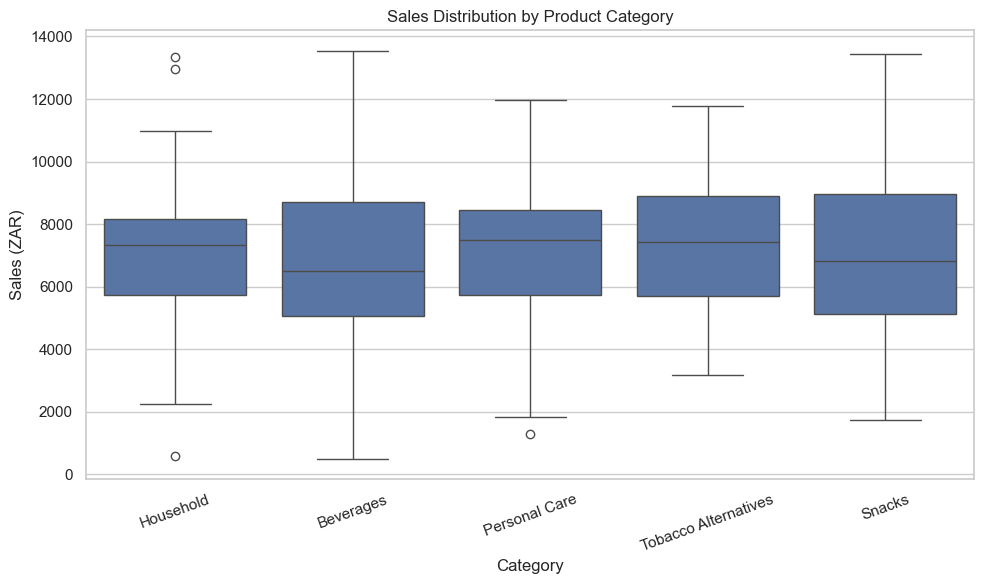

In [54]:
# Chart 2: Box plot — sales distribution per category

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="category", y="sales_zar")
plt.title("Sales Distribution by Product Category")
plt.xlabel("Category")
plt.ylabel("Sales (ZAR)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("output/category_boxplot.png", dpi=150)
plt.show()
plt.close()

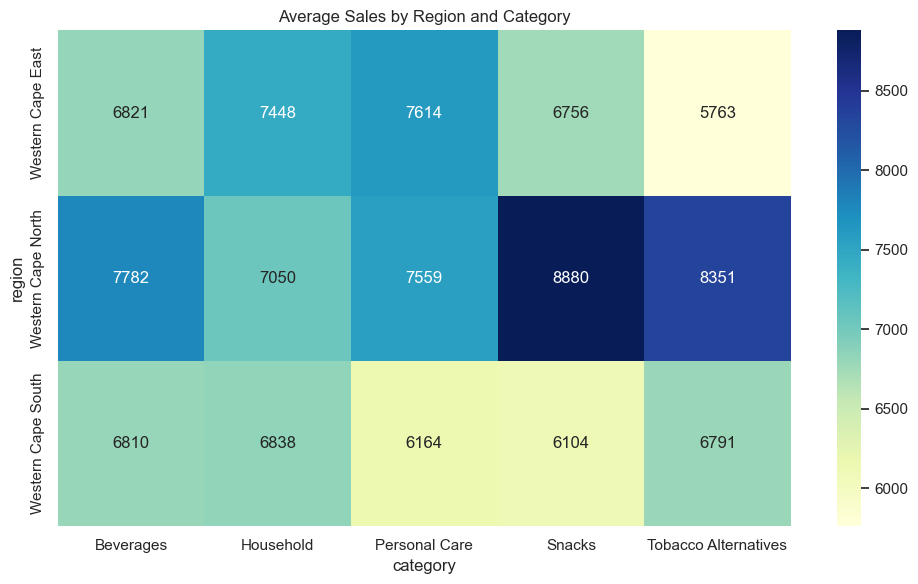


DONE! Charts saved to the 'output/' folder:
  - store_sales_barplot.png
  - category_boxplot.png
  - region_category_heatmap.png


In [55]:
# Chart 3: Heatmap — average sales by region and category

pivot_table = df.pivot_table(
    values="sales_zar", index="region", columns="category", aggfunc="mean"
).round(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Sales by Region and Category")
plt.tight_layout()
plt.savefig("output/region_category_heatmap.png", dpi=150)
plt.show()
plt.close()

print("\n" + "=" * 60)
print("DONE! Charts saved to the 'output/' folder:")
print("  - store_sales_barplot.png")
print("  - category_boxplot.png")
print("  - region_category_heatmap.png")
print("=" * 60)
